In [2]:
import numpy as np
from astropy.cosmology import Flatw0waCDM
from pdspl_utils.inference import draw_lens_from_given_zs, run_dspl_inference
import corner
import matplotlib.pyplot as plt
import matplotlib.lines as mlines

# --- 1. SHARED CONFIGURATION & COSMOLOGY ---
cosmo_true = Flatw0waCDM(H0=70.0, Om0=0.3, w0=-1.0, wa=0.0)

shared_truth = {
    'h0': 70.0, 'om': 0.3, 'w0': -1.0, 'wa': 0.0,
    'lambda_int': 1.0, 'lambda_sigma': 0.05,
    'gamma_pl': 2.078, 'gamma_sigma': 0.16,
    'beta_c1': 0.0, 'beta_c2': 0.0
}

# Constant observational errors
sig_meas, sig_los = 0.01, 0.01
sig_meas_rel = np.sqrt(sig_meas**2 + sig_los**2)

# --- 2. THE OBSERVATIONAL SCENARIOS ---
scenarios = {
    # ==========================================
    # ERA 1: Roman Space Telescope Only
    # ==========================================
    'Roman Standard DSPL': {
        'num_lenses': 500, 'down_sampling': 1, 'true_c0': 0.0, 
        'redshift_error': 0.001, 'color': '#ff7f0e', # Orange
        'gamma_prior': ('uniform', 1.0, 3.0) 
    },
    'Roman Optimistic DSPL': {
        'num_lenses': 500, 'down_sampling': 1, 'true_c0': 0.0, 
        'redshift_error': 0.001, 'color': '#9467bd', # Purple
        # 1% Knowledge prior on the mean from kinematics
        'gamma_prior': ('gaussian', shared_truth['gamma_pl'], 0.01 * shared_truth['gamma_pl']) 
    },
    'Roman PDSPL': {
        'num_lenses': 1000, 'down_sampling': 70, 'true_c0': 0.19, 
        'redshift_error': 0.03, 'color': '#1f77b4', # Blue
        'gamma_prior': ('uniform', 1.0, 3.0)
    },
    
    # ==========================================
    # ERA 2: LSST+Euclid+Roman All-Sky
    # ==========================================
    'LSST+Euclid+Roman Standard DSPL': {
        'num_lenses': 2000, 'down_sampling': 1, 'true_c0': 0.0, 
        'redshift_error': 0.001, 'color': '#ff7f0e', 
        'gamma_prior': ('uniform', 1.0, 3.0) 
    },
    'LSST+Euclid+Roman Optimistic DSPL': {
        'num_lenses': 2000, 'down_sampling': 1, 'true_c0': 0.0, 
        'redshift_error': 0.001, 'color': '#9467bd', 
        # 1% Knowledge prior on the mean from kinematics
        'gamma_prior': ('gaussian', shared_truth['gamma_pl'], 0.01 * shared_truth['gamma_pl']) 
    },
    'LSST+Euclid+Roman PDSPL': {
        'num_lenses': 1000, 'down_sampling': 210, 'true_c0': 0.19, 
        'redshift_error': 0.03, 'color': '#1f77b4', 
        'gamma_prior': ('uniform', 1.0, 3.0)
    }
}

# Dynamically generate the elegant legend labels with effective scatter
for key, sc in scenarios.items():
    eff_scatter = np.sqrt(sc['true_c0']**2 + sig_meas**2 + sig_los**2) * 100
    spec_str = "Spec-z" if sc['redshift_error'] < 0.01 else "Photo-z"
    N_eff = sc['num_lenses'] * sc['down_sampling']
    
    label = f"{key}\n$N = {N_eff:,}$ ({spec_str})\n$\\sigma_{{\\beta_{{\\rm E}}}} = {eff_scatter:.1f}\\%$"
    sc['legend_label'] = label

# --- 3. GENERATE DATA & RUN INFERENCE ---
results = {}
fixed_params = {'h0': 70.0, 'beta_c1': 0.0, 'beta_c2': 0.0}

for key, sc in scenarios.items():
    print(f"\n{'='*60}")
    print(f"Running Inference: {key}")
    print(f"{'='*60}")
    
    np.random.seed(42) # Lock the universe geometry for a fair fight!
    kwargs_list = []
    
    for _ in range(sc['num_lenses']):
        z_lens = np.random.normal(loc=0.5, scale=0.1)
        z1 = np.random.uniform(low=z_lens + 0.1, high=3.0)
        z2 = np.random.uniform(low=z1 + 0.1, high=3.0)
        
        kwargs_list.append(draw_lens_from_given_zs(
            z_lens=z_lens, z1=z1, z2=z2,
            lambda_mst_mean=shared_truth['lambda_int'], lambda_mst_sigma=shared_truth['lambda_sigma'],
            gamma_pl_mean=shared_truth['gamma_pl'], gamma_pl_sigma=shared_truth['gamma_sigma'],
            sigma_beta_intrinsic=sc['true_c0'], sigma_meas_rel=sig_meas_rel,
            dissimilarity=0.0, down_sampling=sc['down_sampling'], 
            with_noise=False, cosmo=cosmo_true, redshift_error_rel=sc['redshift_error']
        ))

    my_guess = {
        'om': 0.3, 'w0': -1.0, 'wa': 0.0,
        'lambda_int': 1.0, 'lambda_sigma': 0.05,
        'gamma_pl': 2.078, 'gamma_sigma': 0.16,
        'beta_c0': sc['true_c0'] 
    }

    my_spreads = {
        'om': 0.05, 'w0': 0.05, 'wa': 0.05,
        'lambda_int': 0.05, 'lambda_sigma': 0.02,
        'gamma_pl': 0.02 if 'Optimistic' in key else 0.05, 
        'gamma_sigma': 0.02 if 'Optimistic' in key else 0.05, # Start closer for tight prior
        'beta_c0': 0.02
    }

    my_priors = {
        'h0': ('uniform', 50.0, 90.0), 'om': ('uniform', 0.0, 1.0),
        'w0': ('uniform', -3.0, 0.0), 'wa': ('uniform', -5.0, 5.0),
        'lambda_int': ('uniform', 0.8, 1.2), 'lambda_sigma': ('uniform', 0.0, 0.2),
        'gamma_pl': sc['gamma_prior'], 
        # 1% Knowledge prior on the scatter applied HERE
        'gamma_sigma': ('gaussian', shared_truth['gamma_sigma'], 0.01*shared_truth['gamma_sigma']) if 'Optimistic' in key else ('uniform', 0.0, 0.5), 
        'beta_c0': ('uniform', -1.0, 1.0)
    }

    samples, labels = run_dspl_inference(
        kwargs_list, down_sampling=sc['down_sampling'],
        n_walkers=64, n_steps=1000, n_burn=500,
        initial_guess=my_guess, initial_scatter=my_spreads,
        fixed_params=fixed_params, priors=my_priors
    )
    
    results[key] = {
        'samples': samples, 'labels': labels, 
        'color': sc['color'], 'legend_label': sc['legend_label'], 'true_c0': sc['true_c0']
    }



Running Inference: Roman Standard DSPL
--- Starting DSPL Inference ---
Fixed Params  : ['h0', 'beta_c1', 'beta_c2']
Sampled Params: ['om', 'w0', 'wa', 'lambda_int', 'lambda_sigma', 'gamma_pl', 'gamma_sigma', 'beta_c0']


100%|██████████| 1000/1000 [01:53<00:00,  8.80it/s]



Running Inference: Roman Optimistic DSPL
--- Starting DSPL Inference ---
Fixed Params  : ['h0', 'beta_c1', 'beta_c2']
Sampled Params: ['om', 'w0', 'wa', 'lambda_int', 'lambda_sigma', 'gamma_pl', 'gamma_sigma', 'beta_c0']


100%|██████████| 1000/1000 [02:01<00:00,  8.26it/s]



Running Inference: Roman PDSPL
--- Starting DSPL Inference ---
Fixed Params  : ['h0', 'beta_c1', 'beta_c2']
Sampled Params: ['om', 'w0', 'wa', 'lambda_int', 'lambda_sigma', 'gamma_pl', 'gamma_sigma', 'beta_c0']


...

100%|██████████| 1000/1000 [04:53<00:00,  3.41it/s]



Running Inference: LSST+Euclid+Roman Optimistic DSPL
--- Starting DSPL Inference ---
Fixed Params  : ['h0', 'beta_c1', 'beta_c2']
Sampled Params: ['om', 'w0', 'wa', 'lambda_int', 'lambda_sigma', 'gamma_pl', 'gamma_sigma', 'beta_c0']


100%|██████████| 1000/1000 [04:57<00:00,  3.36it/s]



Running Inference: LSST+Euclid+Roman PDSPL
--- Starting DSPL Inference ---
Fixed Params  : ['h0', 'beta_c1', 'beta_c2']
Sampled Params: ['om', 'w0', 'wa', 'lambda_int', 'lambda_sigma', 'gamma_pl', 'gamma_sigma', 'beta_c0']


100%|██████████| 1000/1000 [03:04<00:00,  5.43it/s]



Generating plot for: Roman Standard DSPL vs Roman Optimistic DSPL vs Roman PDSPL


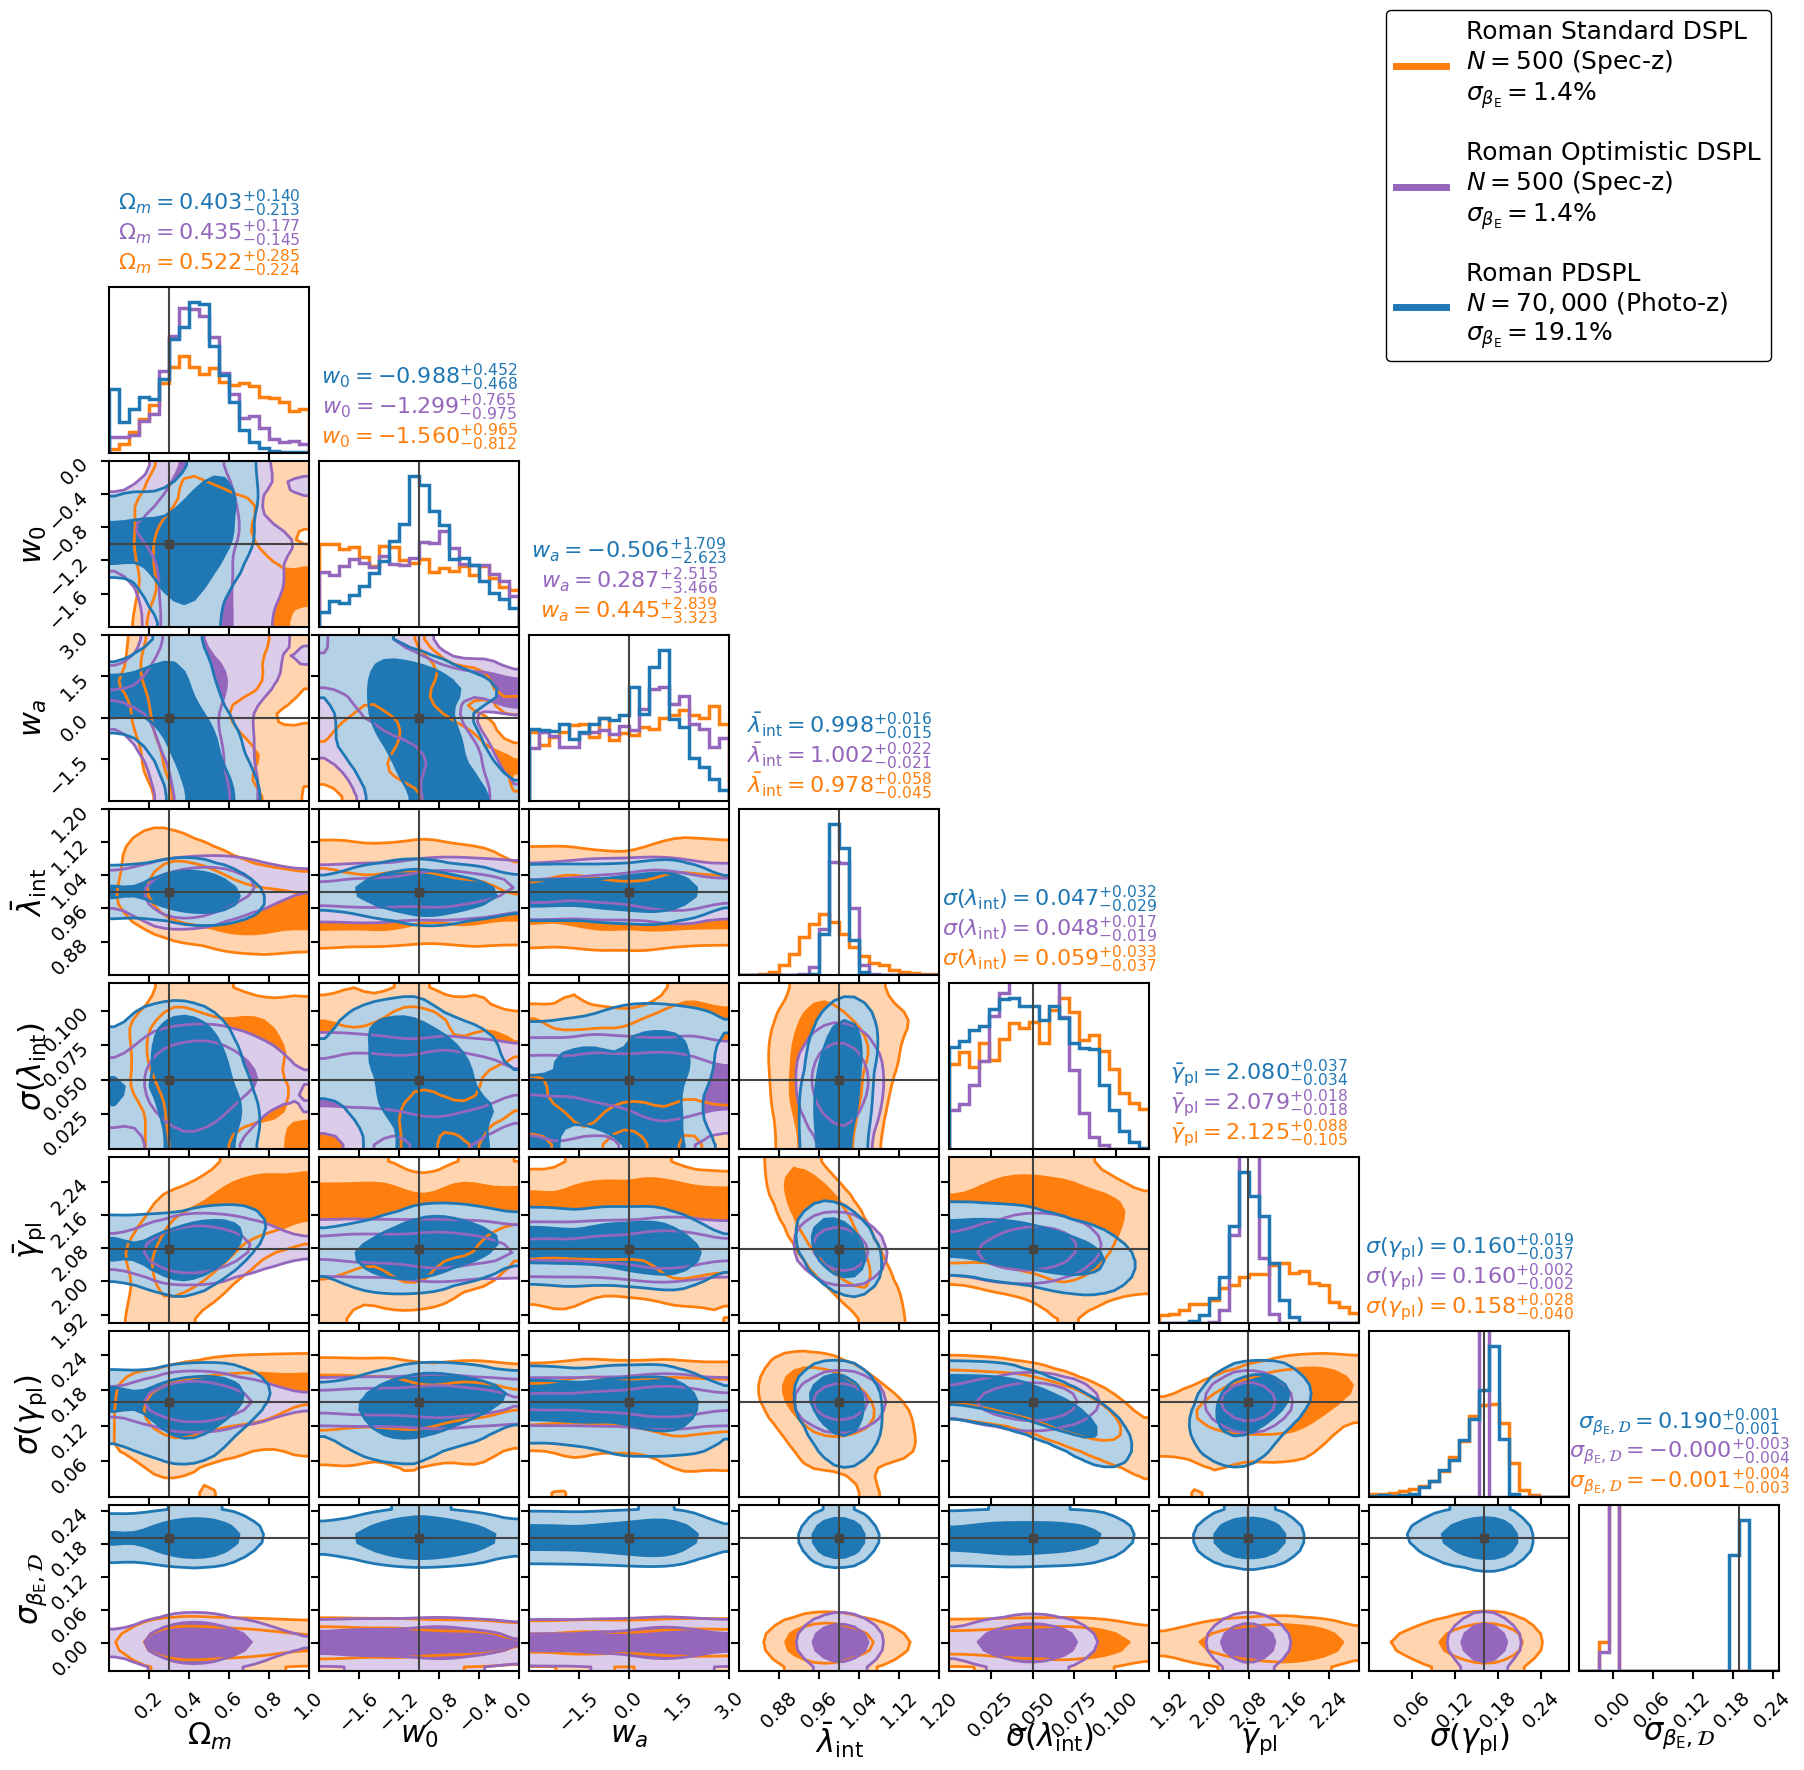


Generating plot for: LSST+Euclid+Roman Standard DSPL vs LSST+Euclid+Roman Optimistic DSPL vs LSST+Euclid+Roman PDSPL


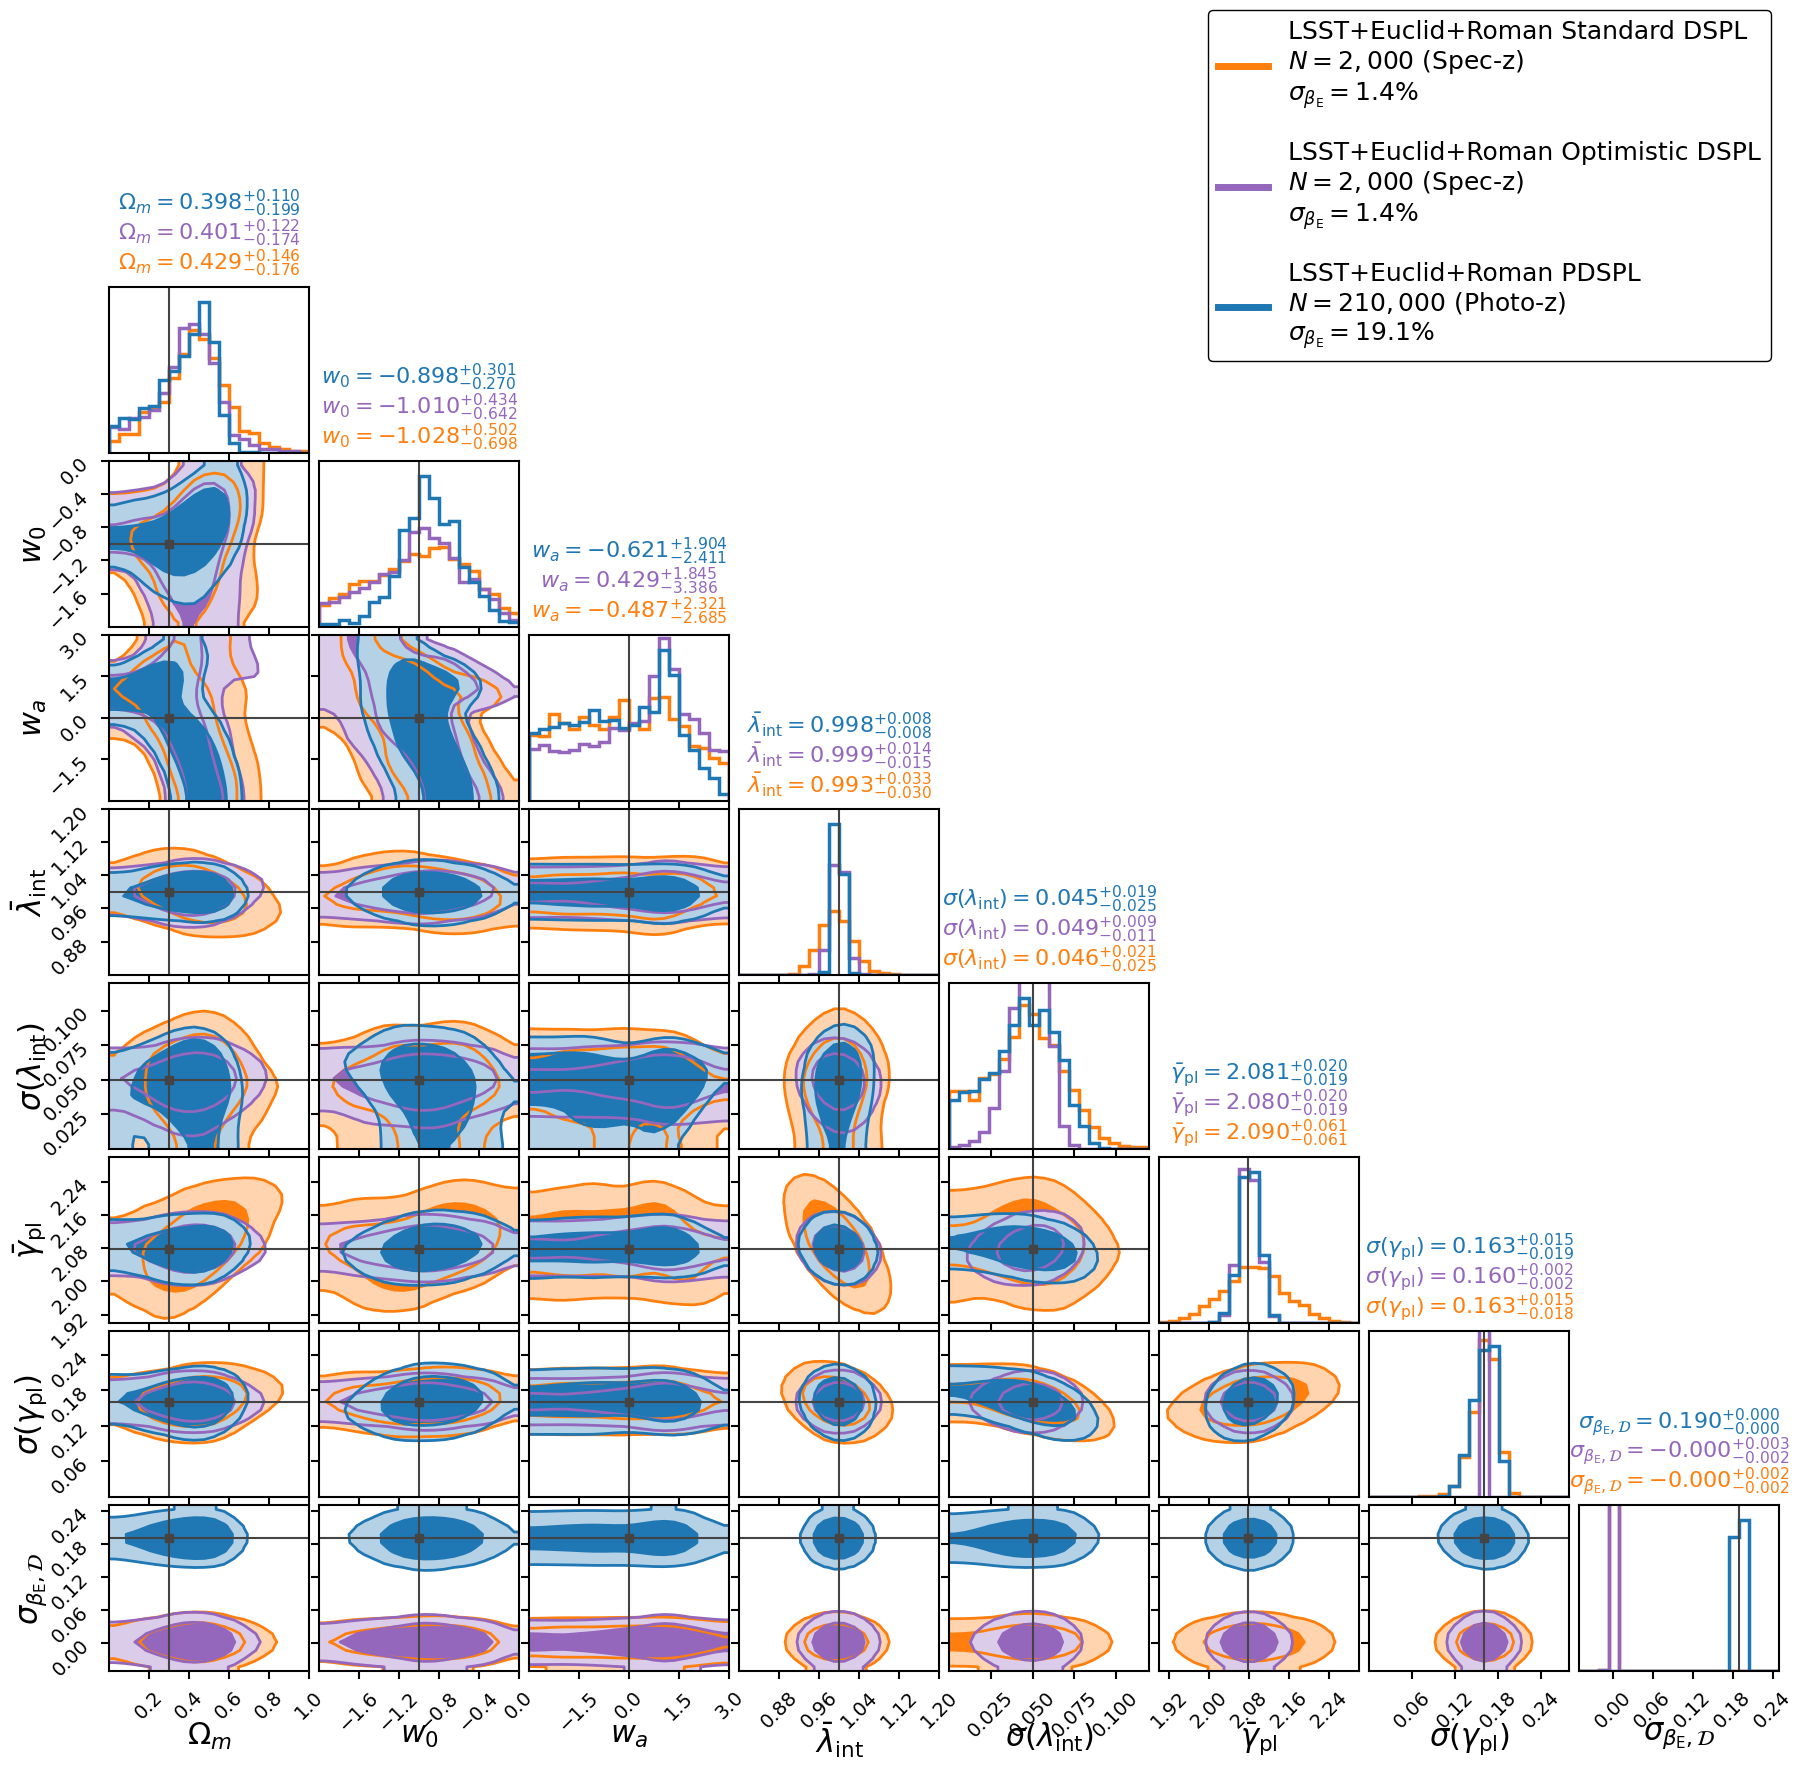

In [5]:
# --- 4. MODULAR PUBLICATION PLOTTING ---
def plot_scenario_comparison(scenario_keys, pdspl_key, filename=None):
    print(f"\nGenerating plot for: {' vs '.join(scenario_keys)}")
    
    # We extract the parameters actually sampled to build the correct truths list
    dummy_sampled_params = [p for p in shared_truth.keys() if p not in fixed_params and p != 'beta_c0']
    dummy_sampled_params.append('beta_c0') # Ensure it's at the end
    
    truth_mapping = shared_truth.copy()
    truth_mapping['beta_c0'] = results[pdspl_key]['true_c0']
    full_truths_list = [truth_mapping[name] for name in dummy_sampled_params]

    ranges = [
        (0, 1), # om
        (-2, 0), # w0
        (-3.0, 3.0), # wa
        (0.8, 1.2), # lambda_int
        (0.0, 0.12), # lambda_sigma
        (1.9, 2.3), # gamma_pl
        (0.0, 0.28), # gamma_sigma
        (-0.05, 0.25) # beta_c0
    ]

    fig = None
    for key in scenario_keys:
        res = results[key]
        fig = corner.corner(
            res['samples'], fig=fig, labels=res['labels'], range=ranges,
            truths=full_truths_list if key == pdspl_key else None, 
            truth_color="#444444", color=res['color'], smooth=1.5,
            plot_datapoints=False, plot_density=False, fill_contours=True,
            levels=[0.68, 0.95],
            hist_kwargs={"density": True, "linewidth": 2.5, "histtype": "step"},
            contour_kwargs={"linewidths": 2.0},
            label_kwargs={"fontsize": 22}, show_titles=False
        )

    # Stacked Multi-colored Titles
    ndim = len(dummy_sampled_params)
    axes = np.array(fig.axes).reshape((ndim, ndim))

    for i in range(ndim):
        ax = axes[i, i]
        for row_idx, key in enumerate(scenario_keys):
            res = results[key]
            samples_1d = res['samples'][:, i]
            q16, q50, q84 = np.percentile(samples_1d, [16, 50, 84])
            
            clean_label = res['labels'][i].replace('$', '')
            title_str = fr"${clean_label} = {q50:.3f}^{{+{q84-q50:.3f}}}_{{-{q50-q16:.3f}}}$"
            
            y_offset = 1.05 + (0.18 * row_idx) 
            ax.text(0.5, y_offset, title_str, transform=ax.transAxes, 
                    ha='center', va='bottom', color=res['color'], fontsize=16)

    # Rich Legend
    legend_handles = [
        mlines.Line2D([], [], color=results[k]['color'], linewidth=5, label=results[k]['legend_label']) 
        for k in scenario_keys
    ]

    fig.legend(
        handles=legend_handles, loc='upper right', bbox_to_anchor=(0.98, 0.98), 
        bbox_transform=fig.transFigure, fontsize=18, frameon=True,
        facecolor='white', framealpha=1.0, edgecolor='black', labelspacing=1.2
    )

    for ax in fig.get_axes():
        ax.tick_params(axis='both', which='major', labelsize=14, pad=6, width=1.5, length=6)
        for spine in ax.spines.values(): spine.set_linewidth(1.5)

    fig.subplots_adjust(top=0.82) 
    
    if filename:
        plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.show()

# --- 5. GENERATE THE FIGURES ---
# Figure A: Roman Era
plot_scenario_comparison(
    scenario_keys=['Roman Standard DSPL', 'Roman Optimistic DSPL', 'Roman PDSPL'], 
    pdspl_key='Roman PDSPL',
    filename='Roman_Era_Forecast.png'
)

# Figure B: Combined Era
plot_scenario_comparison(
    scenario_keys=['LSST+Euclid+Roman Standard DSPL', 'LSST+Euclid+Roman Optimistic DSPL', 'LSST+Euclid+Roman PDSPL'], 
    pdspl_key='LSST+Euclid+Roman PDSPL',
    filename='Combined_Era_Forecast.png'
)

## Fixed scatter forecast


Running Inference: Roman Standard DSPL
--- Starting DSPL Inference ---
Fixed Params  : ['h0', 'beta_c1', 'beta_c2', 'beta_c0']
Sampled Params: ['om', 'w0', 'wa', 'lambda_int', 'lambda_sigma', 'gamma_pl', 'gamma_sigma']


100%|██████████| 1000/1000 [01:58<00:00,  8.46it/s]



Running Inference: Roman Optimistic DSPL
--- Starting DSPL Inference ---
Fixed Params  : ['h0', 'beta_c1', 'beta_c2', 'beta_c0']
Sampled Params: ['om', 'w0', 'wa', 'lambda_int', 'lambda_sigma', 'gamma_pl', 'gamma_sigma']


100%|██████████| 1000/1000 [02:10<00:00,  7.69it/s]



Running Inference: Roman PDSPL
--- Starting DSPL Inference ---
Fixed Params  : ['h0', 'beta_c1', 'beta_c2', 'beta_c0']
Sampled Params: ['om', 'w0', 'wa', 'lambda_int', 'lambda_sigma', 'gamma_pl', 'gamma_sigma']


...


Running Inference: LSST+Euclid+Roman Optimistic DSPL
--- Starting DSPL Inference ---
Fixed Params  : ['h0', 'beta_c1', 'beta_c2', 'beta_c0']
Sampled Params: ['om', 'w0', 'wa', 'lambda_int', 'lambda_sigma', 'gamma_pl', 'gamma_sigma']


100%|██████████| 1000/1000 [04:57<00:00,  3.36it/s]



Running Inference: LSST+Euclid+Roman PDSPL
--- Starting DSPL Inference ---
Fixed Params  : ['h0', 'beta_c1', 'beta_c2', 'beta_c0']
Sampled Params: ['om', 'w0', 'wa', 'lambda_int', 'lambda_sigma', 'gamma_pl', 'gamma_sigma']


100%|██████████| 1000/1000 [03:04<00:00,  5.43it/s]



Generating plot for: Roman Standard DSPL vs Roman Optimistic DSPL vs Roman PDSPL


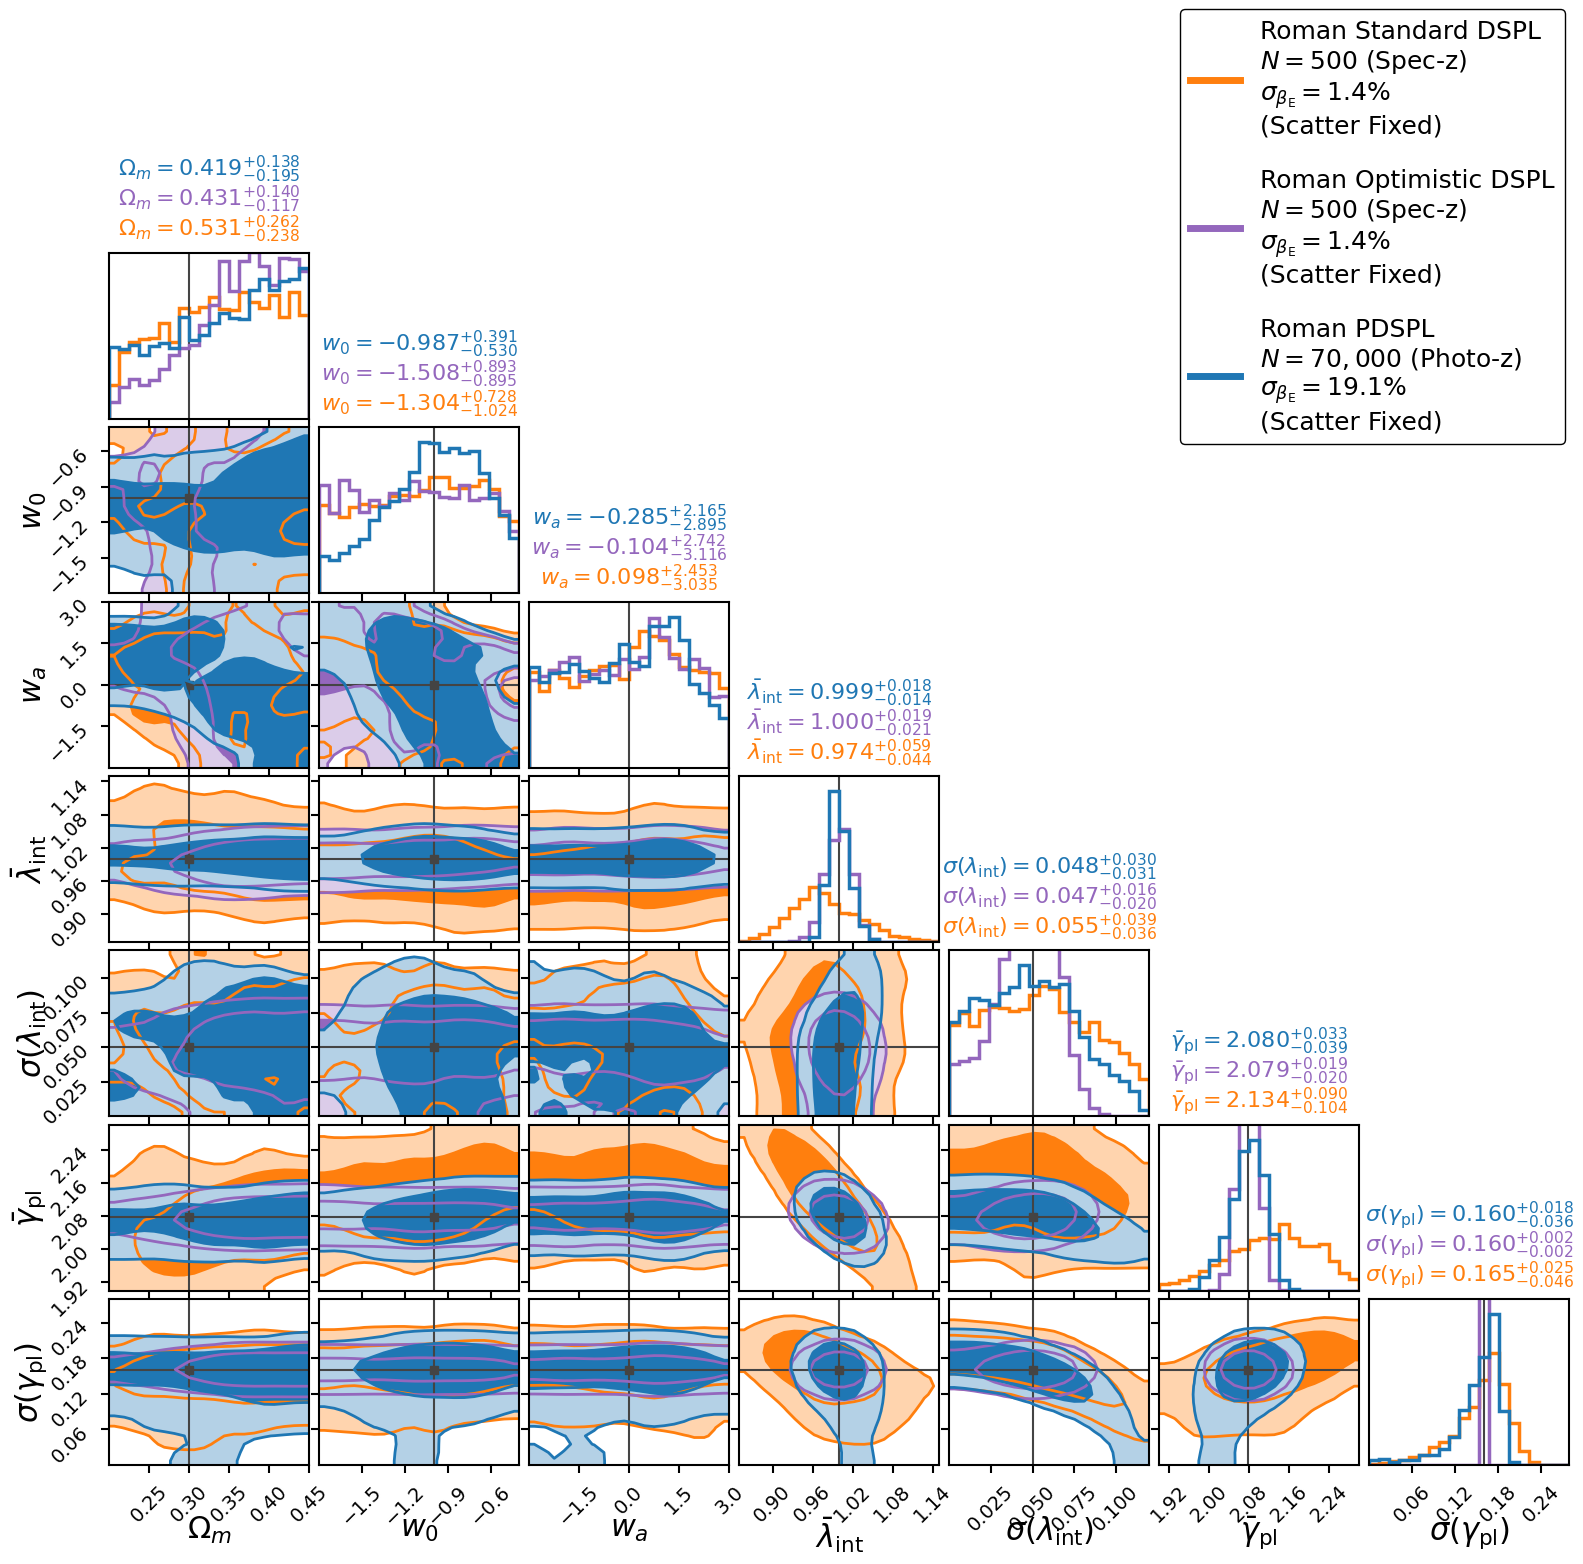


Generating plot for: LSST+Euclid+Roman Standard DSPL vs LSST+Euclid+Roman Optimistic DSPL vs LSST+Euclid+Roman PDSPL


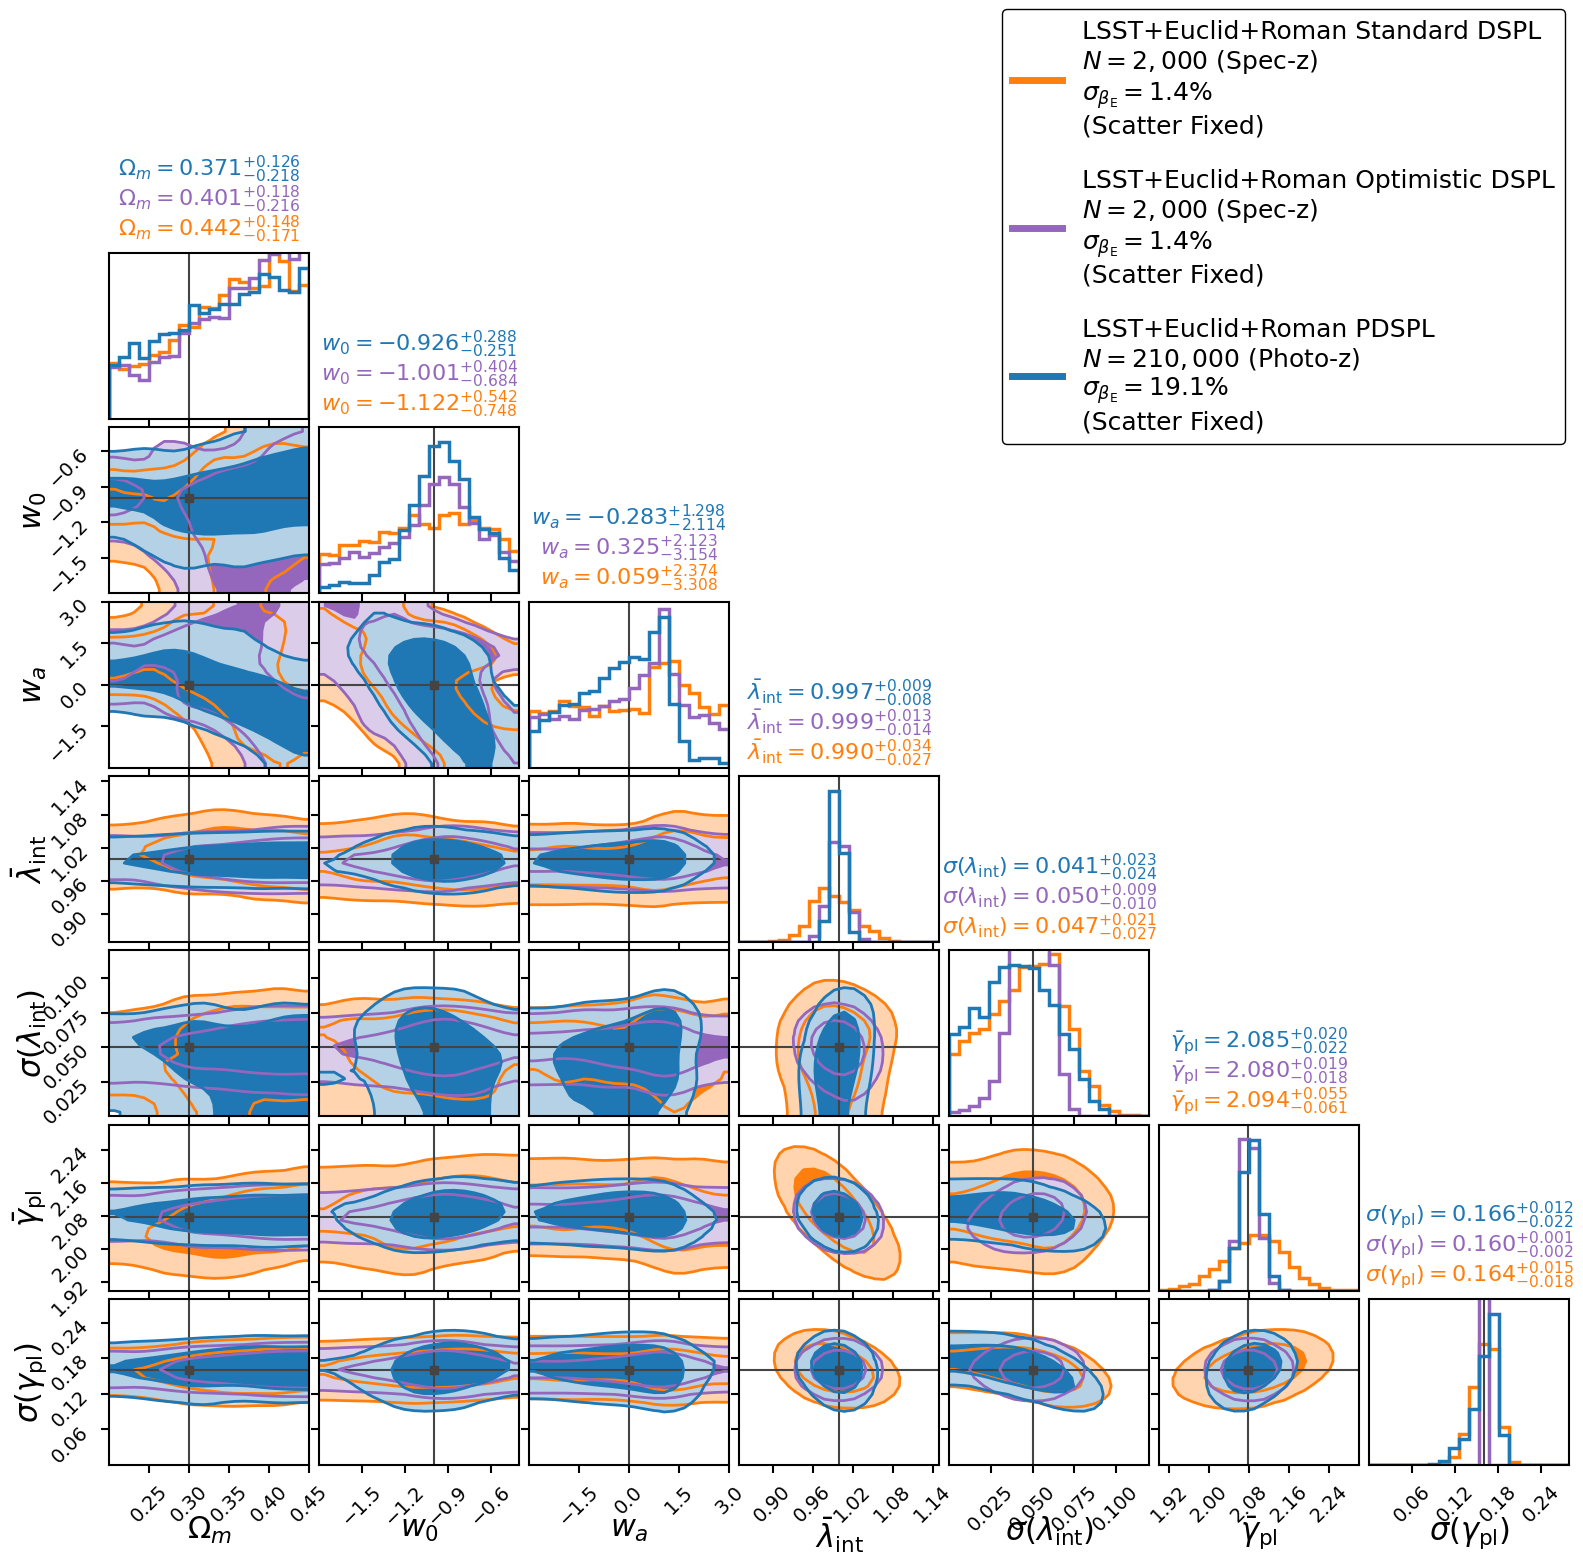

In [ ]:
import numpy as np
from astropy.cosmology import Flatw0waCDM
from pdspl_utils.inference import draw_lens_from_given_zs, run_dspl_inference
import corner
import matplotlib.pyplot as plt
import matplotlib.lines as mlines

# --- 1. SHARED CONFIGURATION & COSMOLOGY ---
cosmo_true = Flatw0waCDM(H0=70.0, Om0=0.3, w0=-1.0, wa=0.0)

shared_truth = {
    'h0': 70.0, 'om': 0.3, 'w0': -1.0, 'wa': 0.0,
    'lambda_int': 1.0, 'lambda_sigma': 0.05,
    'gamma_pl': 2.078, 'gamma_sigma': 0.16,
    'beta_c1': 0.0, 'beta_c2': 0.0
}

# Constant observational errors
sig_meas, sig_los = 0.01, 0.01
sig_meas_rel = np.sqrt(sig_meas**2 + sig_los**2)

# --- 2. THE OBSERVATIONAL SCENARIOS ---
scenarios = {
    # ==========================================
    # ERA 1: Roman Space Telescope Only
    # ==========================================
    'Roman Standard DSPL': {
        'num_lenses': 500, 'down_sampling': 1, 'true_c0': 0.0, 
        'redshift_error': 0.001, 'color': '#ff7f0e', # Orange
        'gamma_prior': ('uniform', 1.0, 3.0) 
    },
    'Roman Optimistic DSPL': {
        'num_lenses': 500, 'down_sampling': 1, 'true_c0': 0.0, 
        'redshift_error': 0.001, 'color': '#9467bd', # Purple
        'gamma_prior': ('gaussian', shared_truth['gamma_pl'], 0.01 * shared_truth['gamma_pl']) 
    },
    'Roman PDSPL': {
        'num_lenses': 1000, 'down_sampling': 70, 'true_c0': 0.19, 
        'redshift_error': 0.03, 'color': '#1f77b4', # Blue
        'gamma_prior': ('uniform', 1.0, 3.0)
    },
    
    # ==========================================
    # ERA 2: LSST+Euclid+Roman All-Sky
    # ==========================================
    'LSST+Euclid+Roman Standard DSPL': {
        'num_lenses': 2000, 'down_sampling': 1, 'true_c0': 0.0, 
        'redshift_error': 0.001, 'color': '#ff7f0e', 
        'gamma_prior': ('uniform', 1.0, 3.0) 
    },
    'LSST+Euclid+Roman Optimistic DSPL': {
        'num_lenses': 2000, 'down_sampling': 1, 'true_c0': 0.0, 
        'redshift_error': 0.001, 'color': '#9467bd', 
        'gamma_prior': ('gaussian', shared_truth['gamma_pl'], 0.01 * shared_truth['gamma_pl']) 
    },
    'LSST+Euclid+Roman PDSPL': {
        'num_lenses': 1000, 'down_sampling': 210, 'true_c0': 0.19, 
        'redshift_error': 0.03, 'color': '#1f77b4', 
        'gamma_prior': ('uniform', 1.0, 3.0)
    }
}

# Dynamically generate the elegant legend labels
for key, sc in scenarios.items():
    eff_scatter = np.sqrt(sc['true_c0']**2 + sig_meas**2 + sig_los**2) * 100
    spec_str = "Spec-z" if sc['redshift_error'] < 0.01 else "Photo-z"
    N_eff = sc['num_lenses'] * sc['down_sampling']
    
    label = f"{key}\n$N = {N_eff:,}$ ({spec_str})\n$\\sigma_{{\\beta_{{\\rm E}}}} = {eff_scatter:.1f}\\%$\n(Scatter Fixed)"
    sc['legend_label'] = label

# --- 3. GENERATE DATA & RUN INFERENCE ---
results = {}

for key, sc in scenarios.items():
    print(f"\n{'='*60}")
    print(f"Running Inference: {key}")
    print(f"{'='*60}")
    
    np.random.seed(42) 
    kwargs_list = []
    
    for _ in range(sc['num_lenses']):
        z_lens = np.random.normal(loc=0.5, scale=0.1)
        z1 = np.random.uniform(low=z_lens + 0.1, high=3.0)
        z2 = np.random.uniform(low=z1 + 0.1, high=3.0)
        
        kwargs_list.append(draw_lens_from_given_zs(
            z_lens=z_lens, z1=z1, z2=z2,
            lambda_mst_mean=shared_truth['lambda_int'], lambda_mst_sigma=shared_truth['lambda_sigma'],
            gamma_pl_mean=shared_truth['gamma_pl'], gamma_pl_sigma=shared_truth['gamma_sigma'],
            sigma_beta_intrinsic=sc['true_c0'], sigma_meas_rel=sig_meas_rel,
            dissimilarity=0.0, down_sampling=sc['down_sampling'], 
            with_noise=False, cosmo=cosmo_true, redshift_error_rel=sc['redshift_error']
        ))

    # --- THE MAGIC BULLET ---
    # By adding beta_c0 to fixed_params, the MCMC ignores it completely!
    fixed_params = {
        'h0': 70.0, 
        'beta_c1': 0.0, 
        'beta_c2': 0.0,
        'beta_c0': sc['true_c0'] 
    }

    my_guess = {
        'om': 0.3, 'w0': -1.0, 'wa': 0.0,
        'lambda_int': 1.0, 'lambda_sigma': 0.05,
        'gamma_pl': 2.078, 'gamma_sigma': 0.16
    }

    my_spreads = {
        'om': 0.05, 'w0': 0.05, 'wa': 0.05,
        'lambda_int': 0.05, 'lambda_sigma': 0.02,
        'gamma_pl': 0.02 if 'Optimistic' in key else 0.05, 
        'gamma_sigma': 0.02 if 'Optimistic' in key else 0.05
    }

    my_priors = {
        'h0': ('uniform', 50.0, 90.0), 'om': ('uniform', 0.0, 1.0),
        'w0': ('uniform', -3.0, 0.0), 'wa': ('uniform', -5.0, 5.0),
        'lambda_int': ('uniform', 0.8, 1.2), 'lambda_sigma': ('uniform', 0.0, 0.2),
        'gamma_pl': sc['gamma_prior'], 
        'gamma_sigma': ('gaussian', shared_truth['gamma_sigma'], 0.01*shared_truth['gamma_sigma']) if 'Optimistic' in key else ('uniform', 0.0, 0.5)
    }

    samples, labels = run_dspl_inference(
        kwargs_list, down_sampling=sc['down_sampling'],
        n_walkers=64, n_steps=1000, n_burn=500,
        initial_guess=my_guess, initial_scatter=my_spreads,
        fixed_params=fixed_params, priors=my_priors
    )
    
    results[key] = {
        'samples': samples, 'labels': labels, 
        'color': sc['color'], 'legend_label': sc['legend_label'], 
        'fixed_params': fixed_params # Save this so the plotter knows what was fixed!
    }




Generating plot for: Roman Standard DSPL vs Roman Optimistic DSPL vs Roman PDSPL


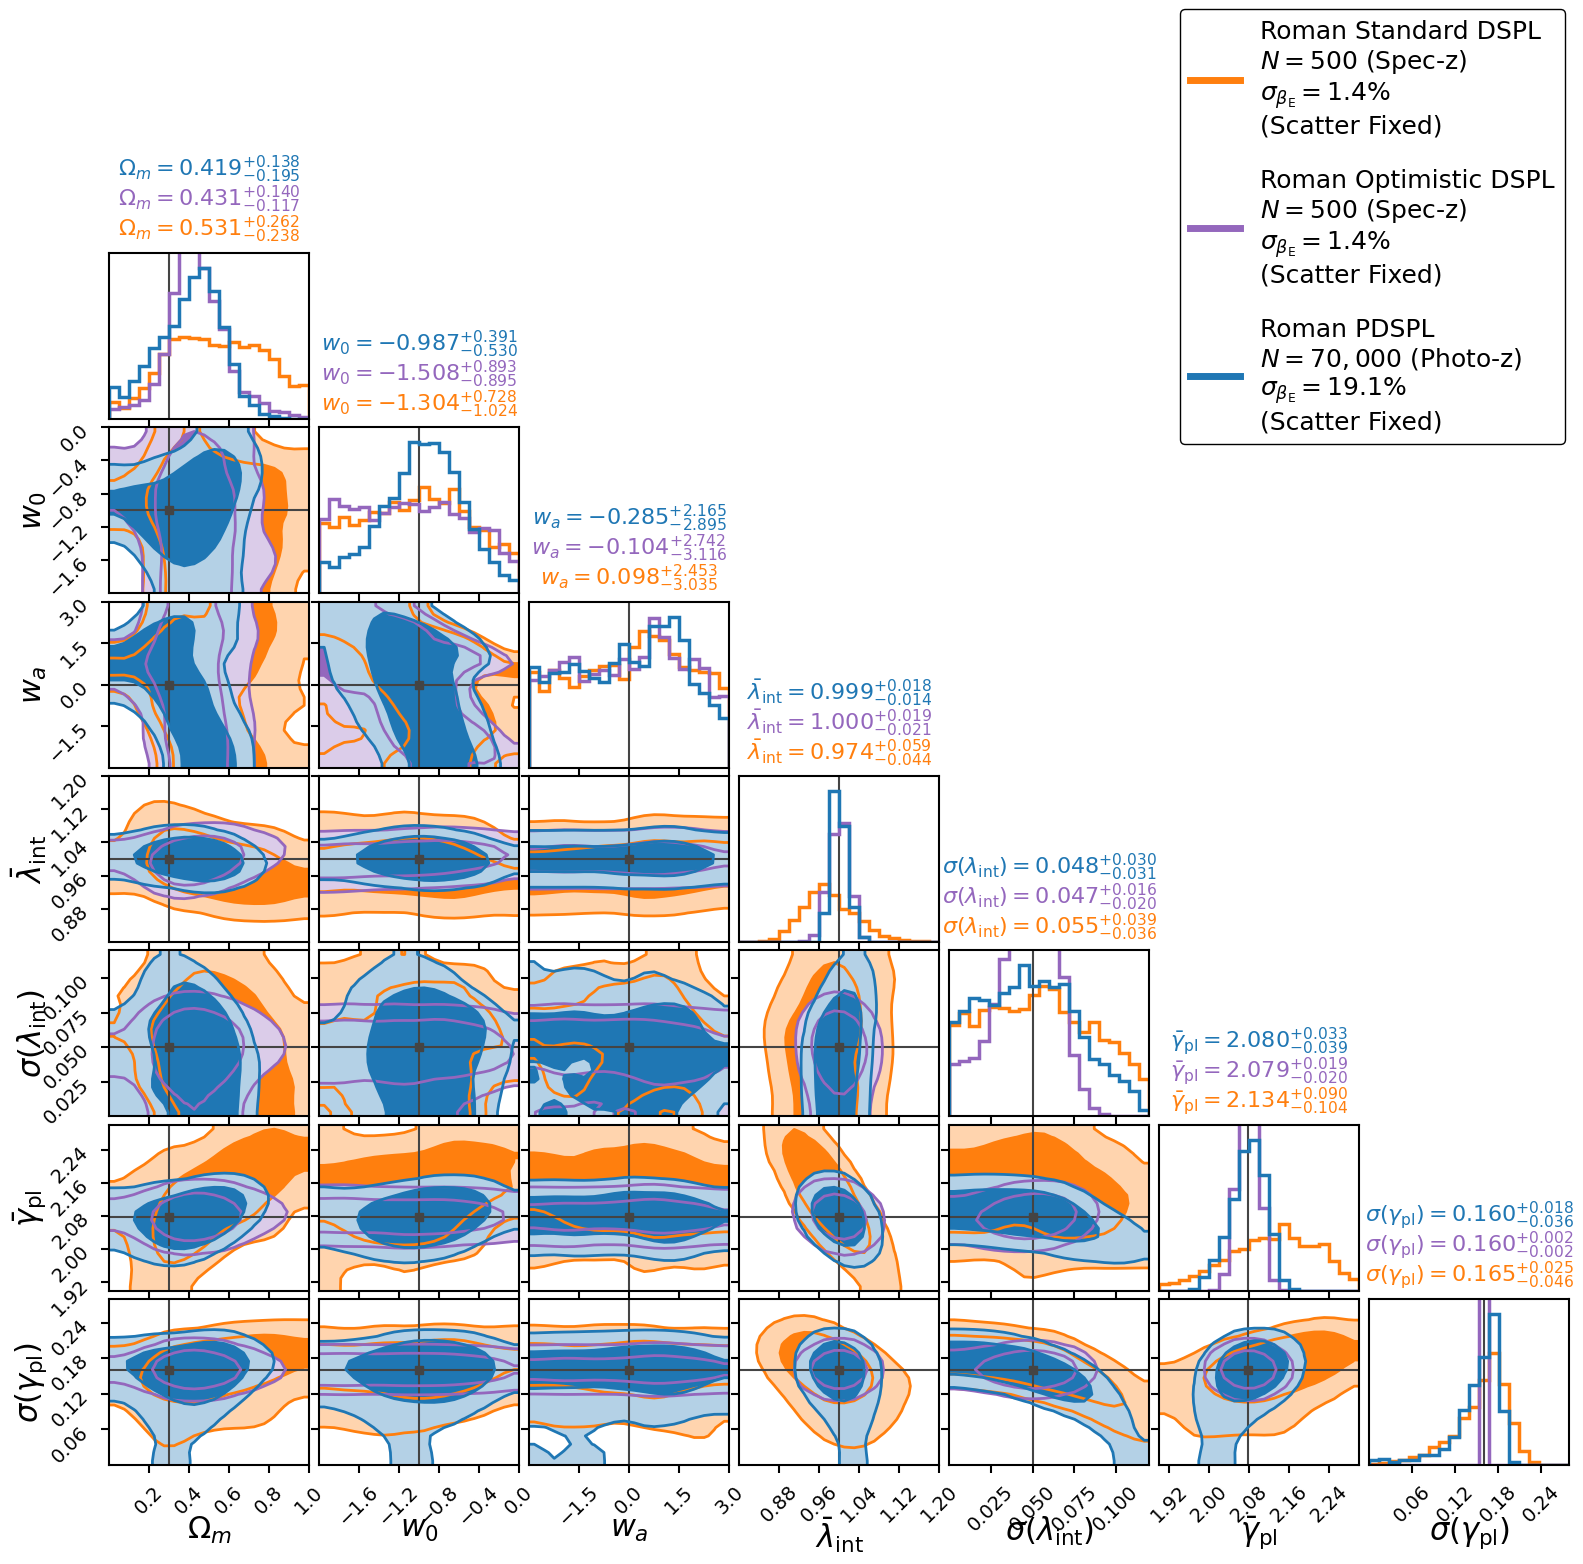


Generating plot for: LSST+Euclid+Roman Standard DSPL vs LSST+Euclid+Roman Optimistic DSPL vs LSST+Euclid+Roman PDSPL


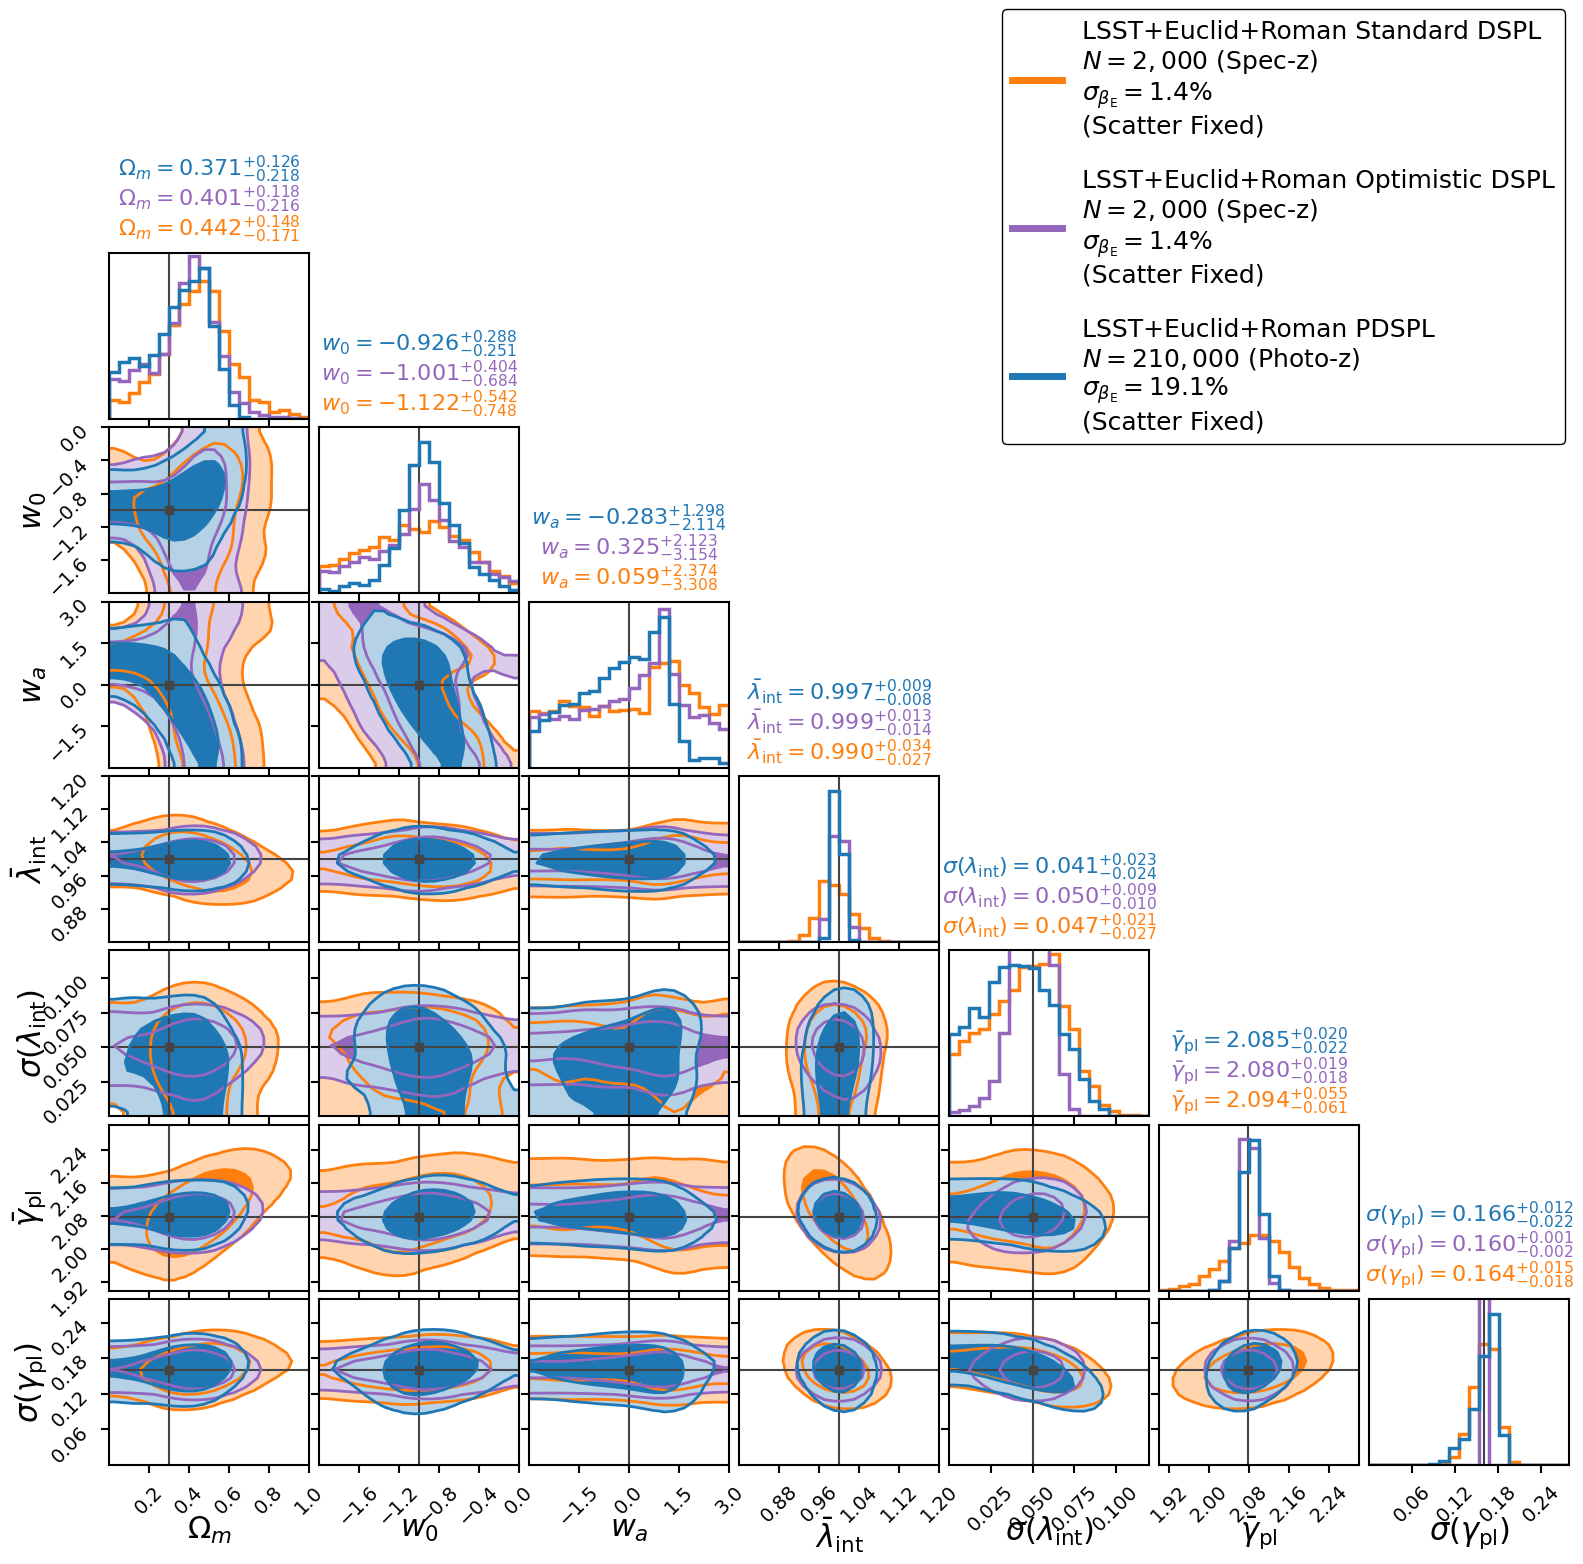

In [8]:
# --- 4. MODULAR PUBLICATION PLOTTING ---
def plot_scenario_comparison(scenario_keys, filename=None):
    print(f"\nGenerating plot for: {' vs '.join(scenario_keys)}")
    
    # We grab the fixed_params from the first scenario to figure out what was sampled
    reference_fixed = results[scenario_keys[0]]['fixed_params']
    sampled_param_names = [p for p in shared_truth.keys() if p not in reference_fixed]
    
    # Build truths dynamically
    full_truths_list = [shared_truth[name] for name in sampled_param_names]

    # Map ranges to parameters dynamically so they don't crash when params are missing
    ranges = [
        (0, 1), # om
        (-2, 0), # w0
        (-3.0, 3.0), # wa
        (0.8, 1.2), # lambda_int
        (0.0, 0.12), # lambda_sigma
        (1.9, 2.3), # gamma_pl
        (0.0, 0.28), # gamma_sigma
    ]

    fig = None
    for idx, key in enumerate(scenario_keys):
        res = results[key]
        fig = corner.corner(
            res['samples'], fig=fig, labels=res['labels'], range=ranges,
            truths=full_truths_list if idx == 0 else None, # Only draw truths once
            truth_color="#444444", color=res['color'], smooth=1.5,
            plot_datapoints=False, plot_density=False, fill_contours=True,
            levels=[0.68, 0.95],
            hist_kwargs={"density": True, "linewidth": 2.5, "histtype": "step"},
            contour_kwargs={"linewidths": 2.0},
            label_kwargs={"fontsize": 22}, show_titles=False
        )

    # Stacked Multi-colored Titles
    ndim = len(sampled_param_names)
    axes = np.array(fig.axes).reshape((ndim, ndim))

    for i in range(ndim):
        ax = axes[i, i]
        for row_idx, key in enumerate(scenario_keys):
            res = results[key]
            samples_1d = res['samples'][:, i]
            q16, q50, q84 = np.percentile(samples_1d, [16, 50, 84])
            
            clean_label = res['labels'][i].replace('$', '')
            title_str = fr"${clean_label} = {q50:.3f}^{{+{q84-q50:.3f}}}_{{-{q50-q16:.3f}}}$"
            
            y_offset = 1.05 + (0.18 * row_idx) 
            ax.text(0.5, y_offset, title_str, transform=ax.transAxes, 
                    ha='center', va='bottom', color=res['color'], fontsize=16)

    # Rich Legend
    legend_handles = [
        mlines.Line2D([], [], color=results[k]['color'], linewidth=5, label=results[k]['legend_label']) 
        for k in scenario_keys
    ]

    fig.legend(
        handles=legend_handles, loc='upper right', bbox_to_anchor=(0.98, 0.98), 
        bbox_transform=fig.transFigure, fontsize=18, frameon=True,
        facecolor='white', framealpha=1.0, edgecolor='black', labelspacing=1.2
    )

    for ax in fig.get_axes():
        ax.tick_params(axis='both', which='major', labelsize=14, pad=6, width=1.5, length=6)
        for spine in ax.spines.values(): spine.set_linewidth(1.5)

    fig.subplots_adjust(top=0.82) 
    
    if filename:
        plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.show()

# --- 5. GENERATE THE FIGURES ---
plot_scenario_comparison(
    scenario_keys=['Roman Standard DSPL', 'Roman Optimistic DSPL', 'Roman PDSPL'], 
    filename='Roman_Era_Forecast_FixedScatter.png'
)

plot_scenario_comparison(
    scenario_keys=['LSST+Euclid+Roman Standard DSPL', 'LSST+Euclid+Roman Optimistic DSPL', 'LSST+Euclid+Roman PDSPL'], 
    filename='Combined_Era_Forecast_FixedScatter.png'
)